# 03. Termal Hedef Sınıflandırma Model Eğitimi (ResNet-18 Backbone)

Bu notebook, önceden ImageNet üzerinde eğitilmiş `ResNet-18` omurgasını kullanarak termal araç (`car`) ve personel (`person`) sınıflarını ayırt etmek üzere transfer öğrenme sürecini yürütür. Sınıf dengesizliğini telafi etmek amacıyla kayıp fonksiyonunda sınıf ağırlıklandırması (`Weighted Cross-Entropy`) kullanılır. Eğitim boyunca en yüksek doğrulama başarımını veren model ağırlıkları `models/best_resnet18.pth` olarak kaydedilir.

In [1]:
import os
import time
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Cihaz yapılandırması (GPU varsa CUDA, yoksa CPU)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Eğitim Cihazı: {device}")

# Veri Dönüşümleri ve Yükleyiciler
DATA_DIR = "../dataset/raw"
train_dir = os.path.join(DATA_DIR, 'train')
val_dir = os.path.join(DATA_DIR, 'validation')

data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=10),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ]),
}

train_dataset = datasets.ImageFolder(train_dir, transform=data_transforms['train'])
val_dataset = datasets.ImageFolder(val_dir, transform=data_transforms['val'])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

# EDA bulgularına göre sınıf ağırlıklandırması (Car: 25.729, Person: 10.133)
# Azınlık sınıfına (Person) daha yüksek ceza katsayısı atanır
class_counts = [25729, 10133]
class_weights = 1.0 / torch.tensor(class_counts, dtype=torch.float)
class_weights = class_weights / class_weights.sum()
class_weights = class_weights.to(device)

print(f"Hesaplanan Sınıf Ağırlıkları (Car, Person): {class_weights}")

Eğitim Cihazı: cuda:0
Hesaplanan Sınıf Ağırlıkları (Car, Person): tensor([0.2826, 0.7174], device='cuda:0')


In [2]:
# Önceden eğitilmiş ResNet-18 modelinin yüklenmesi
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Son tam bağlantılı (Fully Connected) katmanı 2 sınıfa uyarlama
num_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(num_features, 2)
)

# Modeli GPU'ya taşıma
model = model.to(device)

# Ağırlıklandırılmış kayıp fonksiyonu ve optimizasyon algoritması
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=2)

print("Güncellenmiş Çıkış Katmanı:")
print(model.fc)

Güncellenmiş Çıkış Katmanı:
Sequential(
  (0): Dropout(p=0.3, inplace=False)
  (1): Linear(in_features=512, out_features=2, bias=True)
)


In [2]:
import os
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

# GPU temizleme ve cihaz seçimi
torch.cuda.empty_cache()
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Veri Dönüşümleri ve Güvenli DataLoader (num_workers=0)
DATA_DIR = "../dataset/raw"
train_dir = os.path.join(DATA_DIR, 'train')
val_dir = os.path.join(DATA_DIR, 'validation')

data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=10),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ]),
}

train_dataset = datasets.ImageFolder(train_dir, transform=data_transforms['train'])
val_dataset = datasets.ImageFolder(val_dir, transform=data_transforms['val'])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0, pin_memory=True)

# Sınıf ağırlıkları
class_counts = [25729, 10133]
class_weights = 1.0 / torch.tensor(class_counts, dtype=torch.float)
class_weights = (class_weights / class_weights.sum()).to(device)

# ResNet-18 Mimarisi
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
num_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(num_features, 2)
)
model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=2)

# Eğitim Döngüsü
os.makedirs("../models", exist_ok=True)
BEST_MODEL_PATH = "../models/best_resnet18.pth"

EPOCHS = 5
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc = 0.0

start_time = time.time()

for epoch in range(EPOCHS):
    print(f"\n--- Epoch {epoch + 1}/{EPOCHS} ---")
    
    # 1. Eğitim Aşaması
    model.train()
    running_loss, running_corrects = 0.0, 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        _, preds = torch.max(outputs, 1)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)
        
    epoch_train_loss = running_loss / len(train_dataset)
    epoch_train_acc = (running_corrects.double() / len(train_dataset)).item()
    
    # 2. Doğrulama Aşaması
    model.eval()
    val_loss, val_corrects = 0.0, 0
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            _, preds = torch.max(outputs, 1)
            
            val_loss += loss.item() * inputs.size(0)
            val_corrects += torch.sum(preds == labels.data)
            
    epoch_val_loss = val_loss / len(val_dataset)
    epoch_val_acc = (val_corrects.double() / len(val_dataset)).item()
    
    scheduler.step(epoch_val_loss)
    
    history['train_loss'].append(epoch_train_loss)
    history['train_acc'].append(epoch_train_acc)
    history['val_loss'].append(epoch_val_loss)
    history['val_acc'].append(epoch_val_acc)
    
    print(f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f}")
    print(f"Val Loss: {epoch_val_loss:.4f}   | Val Acc: {epoch_val_acc:.4f}")
    
    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print(f">> En iyi model güncellendi ve kaydedildi: Acc = {best_val_acc:.4f}")

elapsed_time = time.time() - start_time
print(f"\nEğitim başarıyla tamamlandı. Toplam Süre: {elapsed_time // 60:.0f}dk {elapsed_time % 60:.0f}sn")


--- Epoch 1/5 ---
Train Loss: 0.0964 | Train Acc: 0.9639
Val Loss: 0.0410   | Val Acc: 0.9857
>> En iyi model güncellendi ve kaydedildi: Acc = 0.9857

--- Epoch 2/5 ---
Train Loss: 0.0541 | Train Acc: 0.9819
Val Loss: 0.0490   | Val Acc: 0.9820

--- Epoch 3/5 ---
Train Loss: 0.0417 | Train Acc: 0.9856
Val Loss: 0.0368   | Val Acc: 0.9872
>> En iyi model güncellendi ve kaydedildi: Acc = 0.9872

--- Epoch 4/5 ---
Train Loss: 0.0352 | Train Acc: 0.9879
Val Loss: 0.0313   | Val Acc: 0.9883
>> En iyi model güncellendi ve kaydedildi: Acc = 0.9883

--- Epoch 5/5 ---
Train Loss: 0.0329 | Train Acc: 0.9890
Val Loss: 0.0407   | Val Acc: 0.9853

Eğitim başarıyla tamamlandı. Toplam Süre: 42dk 38sn


C:\Users\sibel\AppData\Local\Temp\ipykernel_31284\3350158720.py:32: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(BEST_MODEL_PATH, map_locat


--- Sınıflandırma Raporu (ResNet-18) ---
              precision    recall  f1-score   support

         car       0.99      0.99      0.99      5514
      person       0.98      0.98      0.98      1773

    accuracy                           0.99      7287
   macro avg       0.98      0.98      0.98      7287
weighted avg       0.99      0.99      0.99      7287



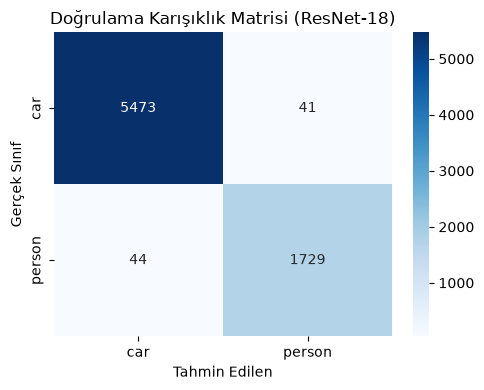

In [2]:
import os
import torch
import torch.nn as nn
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Doğrulama Veri Seti
val_dir = "../dataset/raw/validation"
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_dataset = datasets.ImageFolder(val_dir, transform=val_transform)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0)

# ResNet-18 Model Mimarisi ve Ağırlıkların Yüklenmesi
model = models.resnet18(weights=None)
num_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(num_features, 2)
)

BEST_MODEL_PATH = "../models/best_resnet18.pth"
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
model = model.to(device)
model.eval()

# Tahminlerin Toplanması
all_preds, all_labels = [], []

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# Sınıflandırma Metrikleri Raporu
target_names = list(val_dataset.class_to_idx.keys())
print("\n--- Sınıflandırma Raporu (ResNet-18) ---")
print(classification_report(all_labels, all_preds, target_names=target_names))

# Karışıklık Matrisi (Confusion Matrix)
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title('Doğrulama Karışıklık Matrisi (ResNet-18)')
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek Sınıf')
plt.tight_layout()
plt.show()

In [6]:
import os
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

# 1. Cihaz ve Veri Hazırlığı
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
torch.cuda.empty_cache()

train_dir = "../dataset/raw/train"
val_dir = "../dataset/raw/validation"

transform = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=10),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
}

train_dataset = datasets.ImageFolder(train_dir, transform=transform['train'])
val_dataset = datasets.ImageFolder(val_dir, transform=transform['val'])

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=0, pin_memory=True)

class_weights = 1.0 / torch.tensor([25729, 10133], dtype=torch.float)
class_weights = (class_weights / class_weights.sum()).to(device)

# 2. MobileNetV3-Large Mimarisi
mobilenet = models.mobilenet_v3_large(weights=models.MobileNet_V3_Large_Weights.DEFAULT)
mobilenet.classifier = nn.Sequential(
    nn.Linear(mobilenet.classifier[0].in_features, 1024),
    nn.Hardswish(),
    nn.Dropout(p=0.3),
    nn.Linear(1024, 2)
)
mobilenet = mobilenet.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.AdamW(mobilenet.parameters(), lr=1e-4, weight_decay=1e-2)

best_acc = 0.0
BEST_MOBILENET_PATH = "../models/best_mobilenetv3.pth"
os.makedirs("../models", exist_ok=True)

# 3. Eğitim Döngüsü
print(f"MobileNetV3 eğitimi başladı ({device})...")
start_time = time.time()

for epoch in range(5):
    mobilenet.train()
    running_loss, corrects = 0.0, 0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out = mobilenet(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * x.size(0)
        corrects += (out.argmax(1) == y).sum().item()
        
    train_acc = corrects / len(train_dataset)
    train_loss = running_loss / len(train_dataset)
    
    mobilenet.eval()
    val_loss, val_corrects = 0.0, 0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            out = mobilenet(x)
            loss = criterion(out, y)
            val_loss += loss.item() * x.size(0)
            val_corrects += (out.argmax(1) == y).sum().item()
            
    val_acc = val_corrects / len(val_dataset)
    val_loss = val_loss / len(val_dataset)
    
    print(f"Epoch {epoch+1}/5 -> Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} | Val Loss: {val_loss:.4f}")
    
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(mobilenet.state_dict(), BEST_MOBILENET_PATH)

print(f"Tamamlandı: {(time.time()-start_time)//60:.0f}dk {(time.time()-start_time)%60:.0f}sn | En İyi Val Acc: {best_acc:.4f}")

MobileNetV3 eğitimi başladı (cuda:0)...
Epoch 1/5 -> Train Acc: 0.9603 | Val Acc: 0.9802 | Val Loss: 0.0526
Epoch 2/5 -> Train Acc: 0.9849 | Val Acc: 0.9866 | Val Loss: 0.0357
Epoch 3/5 -> Train Acc: 0.9890 | Val Acc: 0.9894 | Val Loss: 0.0319
Epoch 4/5 -> Train Acc: 0.9922 | Val Acc: 0.9886 | Val Loss: 0.0350
Epoch 5/5 -> Train Acc: 0.9929 | Val Acc: 0.9904 | Val Loss: 0.0310
Tamamlandı: 14dk 14sn | En İyi Val Acc: 0.9904



--- Sınıflandırma Raporu (MobileNetV3-Large) ---
              precision    recall  f1-score   support

         car       0.99      0.99      0.99      5514
      person       0.98      0.98      0.98      1773

    accuracy                           0.99      7287
   macro avg       0.99      0.99      0.99      7287
weighted avg       0.99      0.99      0.99      7287



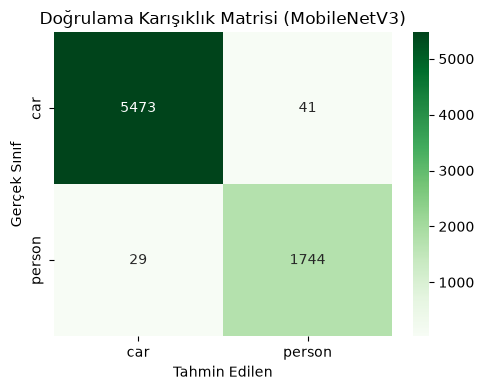

In [2]:
import os
import torch
import torch.nn as nn
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Doğrulama Veri Seti
val_dir = "../dataset/raw/validation"
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_dataset = datasets.ImageFolder(val_dir, transform=val_transform)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=0)

# MobileNetV3 Mimarisinin Kurulması
mobilenet = models.mobilenet_v3_large(weights=None)
in_features = mobilenet.classifier[0].in_features
mobilenet.classifier = nn.Sequential(
    nn.Linear(in_features, 1024),
    nn.Hardswish(),
    nn.Dropout(p=0.3),
    nn.Linear(1024, 2)
)

# Kaydedilen Ağırlıkların Yüklenmesi
BEST_MOBILENET_PATH = "../models/best_mobilenetv3.pth"
mobilenet.load_state_dict(torch.load(BEST_MOBILENET_PATH, map_location=device, weights_only=True))
mobilenet = mobilenet.to(device)
mobilenet.eval()

# Tahminlerin Alınması
mb_preds, mb_labels = [], []

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        outputs = mobilenet(inputs)
        _, preds = torch.max(outputs, 1)
        mb_preds.extend(preds.cpu().numpy())
        mb_labels.extend(labels.numpy())

# Metrik Raporu ve Karışıklık Matrisi
target_names = list(val_dataset.class_to_idx.keys())
print("\n--- Sınıflandırma Raporu (MobileNetV3-Large) ---")
print(classification_report(mb_labels, mb_preds, target_names=target_names))

cm_mb = confusion_matrix(mb_labels, mb_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_mb, annot=True, fmt='d', cmap='Greens', xticklabels=target_names, yticklabels=target_names)
plt.title('Doğrulama Karışıklık Matrisi (MobileNetV3)')
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek Sınıf')
plt.tight_layout()
plt.show()

In [5]:
import os
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
torch.cuda.empty_cache()

# Veri Dönüşümleri ve Güvenli DataLoader (Batch size: 32)
DATA_DIR = "../dataset/raw"
transform = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=10),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
}

train_dataset = datasets.ImageFolder(os.path.join(DATA_DIR, 'train'), transform=transform['train'])
val_dataset = datasets.ImageFolder(os.path.join(DATA_DIR, 'validation'), transform=transform['val'])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0, pin_memory=True)

class_weights = 1.0 / torch.tensor([25729, 10133], dtype=torch.float)
class_weights = (class_weights / class_weights.sum()).to(device)

# DenseNet-121 Modeli
densenet = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)
num_features = densenet.classifier.in_features
densenet.classifier = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(num_features, 2)
)
densenet = densenet.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.AdamW(densenet.parameters(), lr=1e-4, weight_decay=1e-2)

BEST_DENSENET_PATH = "../models/best_densenet121.pth"
best_acc = 0.0
total_batches = len(train_loader)

print(f"DenseNet-121 Eğitimi Başlıyor ({device})... Toplam Batch: {total_batches}")
start_time = time.time()

for epoch in range(5):
    # Eğitim
    densenet.train()
    running_loss, corrects = 0.0, 0
    
    for i, (x, y) in enumerate(train_loader):
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out = densenet(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * x.size(0)
        corrects += (out.argmax(1) == y).sum().item()
        
        if (i + 1) % 200 == 0 or (i + 1) == total_batches:
            print(f"Epoch [{epoch+1}/5] | Batch [{i+1}/{total_batches}] | Anlık Loss: {loss.item():.4f}")
            
    train_acc = corrects / len(train_dataset)
    train_loss = running_loss / len(train_dataset)
    
    # Doğrulama
    densenet.eval()
    val_loss, val_corrects = 0.0, 0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            out = densenet(x)
            loss = criterion(out, y)
            val_loss += loss.item() * x.size(0)
            val_corrects += (out.argmax(1) == y).sum().item()
            
    val_acc = val_corrects / len(val_dataset)
    val_loss = val_loss / len(val_dataset)
    
    print(f"\n--- Sonuç Epoch {epoch+1}/5 -> Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} ---")
    
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(densenet.state_dict(), BEST_DENSENET_PATH)
        print(f">> En iyi model kaydedildi: Acc = {best_acc:.4f}\n")

print(f"DenseNet-121 Tamamlandı. Toplam Süre: {(time.time()-start_time)//60:.0f}dk {(time.time()-start_time)%60:.0f}sn | En İyi Val Acc: {best_acc:.4f}")

DenseNet-121 Eğitimi Başlıyor (cuda:0)... Toplam Batch: 1121
Epoch [1/5] | Batch [200/1121] | Anlık Loss: 0.0412
Epoch [1/5] | Batch [400/1121] | Anlık Loss: 0.1068
Epoch [1/5] | Batch [600/1121] | Anlık Loss: 0.2223
Epoch [1/5] | Batch [800/1121] | Anlık Loss: 0.0187
Epoch [1/5] | Batch [1000/1121] | Anlık Loss: 0.1393
Epoch [1/5] | Batch [1121/1121] | Anlık Loss: 0.0440

--- Sonuç Epoch 1/5 -> Train Loss: 0.0939 | Train Acc: 0.9644 | Val Acc: 0.9881 ---
>> En iyi model kaydedildi: Acc = 0.9881

Epoch [2/5] | Batch [200/1121] | Anlık Loss: 0.0516
Epoch [2/5] | Batch [400/1121] | Anlık Loss: 0.0201
Epoch [2/5] | Batch [600/1121] | Anlık Loss: 0.0207
Epoch [2/5] | Batch [800/1121] | Anlık Loss: 0.0366
Epoch [2/5] | Batch [1000/1121] | Anlık Loss: 0.0342
Epoch [2/5] | Batch [1121/1121] | Anlık Loss: 0.1032

--- Sonuç Epoch 2/5 -> Train Loss: 0.0483 | Train Acc: 0.9830 | Val Acc: 0.9914 ---
>> En iyi model kaydedildi: Acc = 0.9914

Epoch [3/5] | Batch [200/1121] | Anlık Loss: 0.0034
Epoch


--- Sınıflandırma Raporu (DenseNet-121) ---
              precision    recall  f1-score   support

         car       1.00      0.99      0.99      5514
      person       0.98      0.99      0.98      1773

    accuracy                           0.99      7287
   macro avg       0.99      0.99      0.99      7287
weighted avg       0.99      0.99      0.99      7287



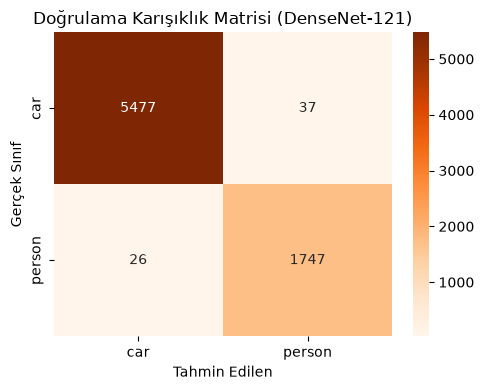

In [6]:
import os
import torch
import torch.nn as nn
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Doğrulama Veri Seti
val_dir = "../dataset/raw/validation"
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_dataset = datasets.ImageFolder(val_dir, transform=val_transform)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0)

# DenseNet-121 Modeli ve Ağırlıkların Yüklenmesi
densenet = models.densenet121(weights=None)
num_features = densenet.classifier.in_features
densenet.classifier = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(num_features, 2)
)

BEST_DENSENET_PATH = "../models/best_densenet121.pth"
densenet.load_state_dict(torch.load(BEST_DENSENET_PATH, map_location=device, weights_only=True))
densenet = densenet.to(device)
densenet.eval()

# Tahminlerin Alınması
dn_preds, dn_labels = [], []
with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        outputs = densenet(inputs)
        _, preds = torch.max(outputs, 1)
        dn_preds.extend(preds.cpu().numpy())
        dn_labels.extend(labels.numpy())

# Metrik Raporu ve Karışıklık Matrisi
target_names = list(val_dataset.class_to_idx.keys())
print("\n--- Sınıflandırma Raporu (DenseNet-121) ---")
print(classification_report(dn_labels, dn_preds, target_names=target_names))

cm_dn = confusion_matrix(dn_labels, dn_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_dn, annot=True, fmt='d', cmap='Oranges', xticklabels=target_names, yticklabels=target_names)
plt.title('Doğrulama Karışıklık Matrisi (DenseNet-121)')
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek Sınıf')
plt.tight_layout()
plt.show()

In [7]:
import os
import time
import torch
import torch.nn as nn
import pandas as pd
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, f1_score

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Doğrulama Veri Seti
val_dir = "../dataset/raw/validation"
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
val_dataset = datasets.ImageFolder(val_dir, transform=val_transform)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0)

# Modellerin Mimarilerini Oluşturma Fonksiyonu
def get_resnet18():
    m = models.resnet18(weights=None)
    m.fc = nn.Sequential(nn.Dropout(0.3), nn.Linear(m.fc.in_features, 2))
    return m

def get_mobilenetv3():
    m = models.mobilenet_v3_large(weights=None)
    m.classifier = nn.Sequential(
        nn.Linear(m.classifier[0].in_features, 1024),
        nn.Hardswish(),
        nn.Dropout(0.3),
        nn.Linear(1024, 2)
    )
    return m

def get_densenet121():
    m = models.densenet121(weights=None)
    m.classifier = nn.Sequential(nn.Dropout(0.3), nn.Linear(m.classifier.in_features, 2))
    return m

model_configs = [
    {"name": "ResNet-18", "fn": get_resnet18, "path": "../models/best_resnet18.pth"},
    {"name": "MobileNetV3-Large", "fn": get_mobilenetv3, "path": "../models/best_mobilenetv3.pth"},
    {"name": "DenseNet-121", "fn": get_densenet121, "path": "../models/best_densenet121.pth"}
]

benchmark_results = []
dummy_input = torch.randn(1, 3, 224, 224).to(device)

print("Modeller Karşılaştırılıyor...\n")

for cfg in model_configs:
    model = cfg["fn"]()
    model.load_state_dict(torch.load(cfg["path"], map_location=device, weights_only=True))
    model = model.to(device)
    model.eval()

    # 1. Parametre Sayısı ve Dosya Boyutu
    param_count = sum(p.numel() for p in model.parameters()) / 1e6
    file_size_mb = os.path.getsize(cfg["path"]) / (1024 * 1024)

    # 2. Gecikme (Latency / FPS) Ölçümü (Warmup + 100 iterasyon)
    with torch.no_grad():
        for _ in range(20):
            _ = model(dummy_input)
        if device.type == 'cuda':
            torch.cuda.synchronize()

        start_lat = time.time()
        for _ in range(100):
            _ = model(dummy_input)
        if device.type == 'cuda':
            torch.cuda.synchronize()
        avg_latency_ms = ((time.time() - start_lat) / 100) * 1000
        fps = 1000.0 / avg_latency_ms

    # 3. Doğrulama Başarımı (Accuracy & F1-Score)
    all_preds, all_labels = [], []
    with torch.no_grad():
        for x, y in val_loader:
            x = x.to(device)
            out = model(x)
            preds = torch.argmax(out, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.numpy())

    acc = accuracy_score(all_labels, all_preds) * 100
    f1 = f1_score(all_labels, all_preds, average='weighted') * 100

    benchmark_results.append({
        "Model": cfg["name"],
        "Doğruluk (%)": f"{acc:.2f}%",
        "F1-Score (%)": f"{f1:.2f}%",
        "Gecikme (ms)": f"{avg_latency_ms:.2f}",
        "FPS": f"{fps:.1f}",
        "Parametre (M)": f"{param_count:.2f}M",
        "Boyut (MB)": f"{file_size_mb:.2f} MB"
    })

df_results = pd.DataFrame(benchmark_results)
display(df_results)

Modeller Karşılaştırılıyor...



,Model,Doğruluk (%),F1-Score (%),Gecikme (ms),FPS,Parametre (M),Boyut (MB)
0,ResNet-18,98.83%,98.83%,3.03,329.5,11.18M,42.71 MB
1,MobileNetV3-Large,99.04%,99.04%,9.09,110.1,3.96M,15.30 MB
2,DenseNet-121,99.14%,99.14%,18.57,53.8,6.96M,27.12 MB
